### MODEL 16
BASELINE + CLS POOLING + EARLYSTOPPING + CLASS WEIGHT
* Split: 80 / 10 / 10
* LR: ReduceLROnPlateau
* Batch size: 16
* Architecture: 128
* Dropout: 0.3
* Permintaan Ibu Rossy


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import random
from scipy.stats import pearsonr
import tensorflow as tf

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, accuracy_score, log_loss, confusion_matrix, recall_score

from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.models import load_model

In [2]:
os.makedirs('hasil_test', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('testing', exist_ok=True)

In [3]:
CONFIG = {
    "split": "80/10/10",          # "80/10/10" atau "70/15/15"
    "lr": 1e-4,
    "batch_size": 16,
    "pooling": "cls",            # "cls" atau "mean"
    "architecture": "128",     # "128-64", "256-128", "128"
    "dropout": 0.3,        # (DO1, DO2)
    "use_class_weight": True,
    "use_early_stopping": True
}

In [4]:
# ID Model
MODEL_ID = "M16_801010_CLS_tesLR"

In [5]:
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
random.seed(42)

In [6]:
# Load Dataset
df_model = pd.read_csv('exposure_job.csv').dropna()
# Gabungkan Title + Tasks
df_model['text'] = df_model['title'] + " [SEP] " + df_model['tasks']
print("Total Occupation:", len(df_model))
df_model.head()

Total Occupation: 1295


,oidn_code,title,tasks,exposure_score,label,text
0,11-0111.00,"Direktur Utama, CEO",mengarahkan dan mengoordinasikan kegiatan keua...,0.000782,0,"Direktur Utama, CEO [SEP] mengarahkan dan meng..."
1,11-0111.01,"Direktur Jenderal, Deputi (Kementerian/Lembaga)",merumuskan kebijakan di bidang tugasnya [SEP] ...,0.002805,0,"Direktur Jenderal, Deputi (Kementerian/Lembaga..."
2,11-0111.02,Direktur Kegiatan & Pendidikan Keagamaan,mengembangkan atau mengarahkan program studi a...,0.001391,0,Direktur Kegiatan & Pendidikan Keagamaan [SEP]...
3,11-0111.03,Direktur Pelaksana,mengatur kinerja dan memberikan arahan tugas k...,0.003830,0,Direktur Pelaksana [SEP] mengatur kinerja dan ...
4,11-0111.04,Direktur Pemrograman Media,mengorganisir pementasan karya seni siaran dan...,0.001505,0,Direktur Pemrograman Media [SEP] mengorganisir...


In [7]:
X_text, y_raw = df_model['text'].values, df_model['label'].values
y = to_categorical(y_raw)

Split Data (NO GROUP SPLIT)

In [8]:
if CONFIG["split"] == "80/10/10":
    test_size, val_ratio = 0.10, 0.111
else: # 70/15/15
    test_size, val_ratio = 0.15, 0.176

indices = np.arange(len(df_model))

X_train_full, X_test_text, y_train_full, y_test, idx_train_full, idx_test = train_test_split(
    X_text, y, indices,
    test_size=test_size,
    stratify=y_raw,
    random_state=42
)

y_train_full_raw = np.argmax(y_train_full, axis=1)

X_train_text, X_val_text, y_train, y_val, idx_train, idx_val = train_test_split(
    X_train_full, y_train_full, idx_train_full,
    test_size=val_ratio,
    stratify=y_train_full_raw,
    random_state=42
)

print("Data Training Awal :", len(X_train_full))
print("Data Training Utama:", len(X_train_text))
print("Data Validation    :", len(X_val_text))
print("Data Testing       :", len(X_test_text))

Data Training Awal : 1165
Data Training Utama: 1035
Data Validation    : 130
Data Testing       : 130


In [9]:
df_test_save = df_model.iloc[idx_test][['oidn_code', 'title', 'tasks', 'exposure_score', 'label', 'text']].copy()
df_test_save.to_csv(f'testing/data_testing_{MODEL_ID}.csv', index=False)

print(f"Data testing {len(df_test_save)} baris berhasil")

Data testing 130 baris berhasil


Load IndoBERT Base (Frozen)

In [10]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
bert_model = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")
bert_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(50000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

Ekstraksi Embedding (CLS Pooling/Mean Pooling)

In [11]:
def get_bert_embedding(text, mode='CLS'):
    inputs = tokenizer(str(text), return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = bert_model(**inputs)

    if mode == 'CLS':
        return outputs.last_hidden_state[:, 0, :].numpy()
    else:
        last_hidden = outputs.last_hidden_state
        attention_mask = inputs['attention_mask']
        mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        masked_embeddings = last_hidden * mask
        summed = torch.sum(masked_embeddings, dim=1)
        summed_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
        return (summed / summed_mask).numpy()

mode_embed = 'CLS' if CONFIG["pooling"] == "cls" else 'MEAN'

print(f"Mengekstrak embedding occupation-level BASELINE {mode_embed} POOLING...")
X_train = np.array([get_bert_embedding(t, mode=mode_embed) for t in X_train_text]).squeeze()
X_val = np.array([get_bert_embedding(t, mode=mode_embed) for t in X_val_text]).squeeze()
X_test = np.array([get_bert_embedding(t, mode=mode_embed) for t in X_test_text]).squeeze()

Mengekstrak embedding occupation-level BASELINE CLS POOLING...


Class Weight, Early Stopping, & Callback LR

In [117]:
class_weight_dict = None
if CONFIG["use_class_weight"]:
    y_train_raw = np.argmax(y_train, axis=1)
    cw = compute_class_weight('balanced', classes=np.unique(y_train_raw), y=y_train_raw)
    class_weight_dict = dict(enumerate(cw))

callbacks = []
if CONFIG["use_early_stopping"]:
    callbacks.append(EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True))

callbacks.append(ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
))

MLP Classifier / Model Architecture

In [118]:
def build_model(arch, dropout):
    model = Sequential()
    if arch == "128-64":
        model.add(Dense(128, activation='relu', input_shape=(768,)))
        model.add(BatchNormalization()); model.add(Dropout(dropout[0]))
        model.add(Dense(64, activation='relu'))
        model.add(BatchNormalization()); model.add(Dropout(dropout[1]))

    elif arch == "256-128":
        model.add(Dense(256, activation='relu', input_shape=(768,)))
        model.add(BatchNormalization()); model.add(Dropout(dropout[0]))
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization()); model.add(Dropout(dropout[1]))

    elif arch == "128":
        model.add(Dense(128, activation='relu', input_shape=(768,)))
        model.add(Dropout(dropout))

    model.add(Dense(2, activation='softmax'))
    return model

In [119]:
model = build_model(CONFIG["architecture"], CONFIG["dropout"])
model.compile(
    optimizer=Adam(learning_rate=CONFIG["lr"]),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training

In [120]:
print(f"Training: {CONFIG['split']} | {CONFIG['pooling']} | {CONFIG['architecture']} | LR={CONFIG['lr']}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=CONFIG["batch_size"],
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Training: 80/10/10 | cls | 128 | LR=0.0001
Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5652 - loss: 0.8079 - val_accuracy: 0.7077 - val_loss: 0.5566 - learning_rate: 1.0000e-04
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6667 - loss: 0.6474 - val_accuracy: 0.6923 - val_loss: 0.5510 - learning_rate: 1.0000e-04
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6860 - loss: 0.5729 - val_accuracy: 0.7615 - val_loss: 0.4850 - learning_rate: 1.0000e-04
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7034 - loss: 0.5567 - val_accuracy: 0.7308 - val_loss: 0.5120 - learning_rate: 1.0000e-04
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7208 - loss: 0.5348 - val_accuracy: 0.7385 - val_loss: 0.4783 - learning_rate: 1.0000e-04
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7324 - loss: 0.5123 - val_accuracy: 0.7846 - val_loss: 0.4494 - learning_rate: 1.0000e-04
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━

#### Evaluasi Model

###### Default Argmax

In [121]:
train_acc = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]
val_acc = history.history['val_accuracy'][-1]
val_loss = history.history['val_loss'][-1]

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

f1 = f1_score(y_true, y_pred, average='weighted')
target_names_str = ['tidak terotomatisasi', 'terotomatisasi']

print("--- EVALUASI MODEL DEFAULT ---")
print(f"Train Accuracy      : {train_acc * 100:.2f}%")
print(f"Train Loss          : {train_loss:.5f}")
print(f"Validation Accuracy : {val_acc * 100:.2f}%")
print(f"Validation Loss     : {val_loss:.5f}")
print(f"Test Accuracy       : {test_acc * 100:.2f}%")
print(f"Test Loss           : {test_loss:.5f}")
print(f"F1 Score (Weighted) : {f1:.4f}")

print("\nClassification Report (Default):\n")
print(classification_report(y_true, y_pred, target_names=target_names_str))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
--- EVALUASI MODEL DEFAULT ---
Train Accuracy      : 84.06%
Train Loss          : 0.34654
Validation Accuracy : 83.85%
Validation Loss     : 0.38028
Test Accuracy       : 81.54%
Test Loss           : 0.41815
F1 Score (Weighted) : 0.8154

Classification Report (Default):

                      precision    recall  f1-score   support

tidak terotomatisasi       0.88      0.88      0.88        97
      terotomatisasi       0.64      0.64      0.64        33

            accuracy                           0.82       130
           macro avg       0.76      0.76      0.76       130
        weighted avg       0.82      0.82      0.82       130



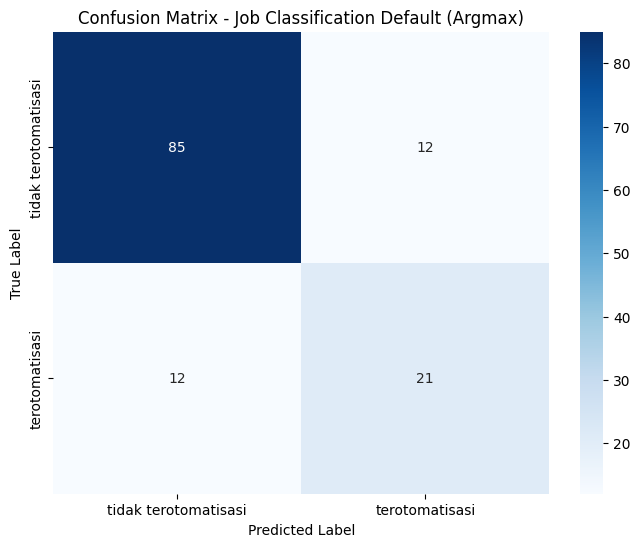

In [122]:
# Confusion Matrix Default
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names_str, yticklabels=target_names_str)
plt.title('Confusion Matrix - Job Classification Default (Argmax)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###### Threshold Tuning

In [123]:
y_proba = model.predict(X_test)
y_proba_high = y_proba[:, 1]

y_true = np.argmax(y_test, axis=1)
print(y_proba_high)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[0.0545732  0.3340337  0.7759533  0.00785599 0.24418423 0.5786094
 0.5850598  0.02853428 0.21448666 0.55881435 0.34877625 0.6321553
 0.6933568  0.10446854 0.25019512 0.06179921 0.01201024 0.02162899
 0.08294298 0.12147186 0.85306126 0.00289823 0.04380032 0.04653151
 0.04565463 0.3285547  0.43194774 0.5037685  0.06889433 0.00374681
 0.00119292 0.45565215 0.1586929  0.27804852 0.83263385 0.5635735
 0.26180258 0.41979268 0.60627836 0.48440897 0.07791154 0.09785204
 0.3705512  0.16441387 0.15170097 0.12734471 0.858388   0.31788045
 0.02599935 0.81079185 0.5551742  0.33551627 0.14830679 0.01737647
 0.29070854 0.8628226  0.05864931 0.36533844 0.59812033 0.22698458
 0.02888662 0.01246801 0.36312786 0.26498586 0.05567792 0.01689532
 0.6822984  0.4058078  0.02408247 0.8170056  0.15072419 0.05843375
 0.05697386 0.06612147 0.70533085 0.49730486 0.04828625 0.12197727
 0.45480767 0.54414654 0.23920575 0.02557261 0.33184937 0.44209877
 0.23505044 0.98058575 0.05

In [124]:
thresholds = np.arange(0.3, 0.7, 0.01)
best_threshold = 0
best_f1 = 0
best_y_pred = None

for t in thresholds:
    y_pred_temp = (y_proba_high >= t).astype(int)
    f1_weighted = f1_score(y_true, y_pred_temp, average='weighted')
    f1_macro = f1_score(y_true, y_pred_temp, average='macro')

    if f1_weighted > best_f1:
        best_f1 = f1_weighted
        best_threshold = t
        best_y_pred = y_pred_temp

    print(f"\nThreshold: {t}")
    print(f"Weighted F1: {f1_weighted:.4f}")
    print(f"Macro F1   : {f1_macro:.4f}")


Threshold: 0.3
Weighted F1: 0.7400
Macro F1   : 0.6908

Threshold: 0.31
Weighted F1: 0.7538
Macro F1   : 0.7046

Threshold: 0.32
Weighted F1: 0.7607
Macro F1   : 0.7116

Threshold: 0.33
Weighted F1: 0.7676
Macro F1   : 0.7186

Threshold: 0.34
Weighted F1: 0.7736
Macro F1   : 0.7220

Threshold: 0.35000000000000003
Weighted F1: 0.7804
Macro F1   : 0.7292

Threshold: 0.36000000000000004
Weighted F1: 0.7804
Macro F1   : 0.7292

Threshold: 0.37000000000000005
Weighted F1: 0.7862
Macro F1   : 0.7325

Threshold: 0.38000000000000006
Weighted F1: 0.7929
Macro F1   : 0.7397

Threshold: 0.39000000000000007
Weighted F1: 0.7929
Macro F1   : 0.7397

Threshold: 0.4000000000000001
Weighted F1: 0.7929
Macro F1   : 0.7397

Threshold: 0.4100000000000001
Weighted F1: 0.7997
Macro F1   : 0.7470

Threshold: 0.4200000000000001
Weighted F1: 0.8065
Macro F1   : 0.7544

Threshold: 0.4300000000000001
Weighted F1: 0.8133
Macro F1   : 0.7619

Threshold: 0.4400000000000001
Weighted F1: 0.8201
Macro F1   : 0.7695



In [125]:
print(f"\n=== Classification Report (Best Threshold = {best_threshold}) ===")
print(classification_report(y_true, best_y_pred, target_names=target_names_str))


=== Classification Report (Best Threshold = 0.48000000000000015) ===
                      precision    recall  f1-score   support

tidak terotomatisasi       0.89      0.88      0.89        97
      terotomatisasi       0.66      0.70      0.68        33

            accuracy                           0.83       130
           macro avg       0.78      0.79      0.78       130
        weighted avg       0.83      0.83      0.83       130



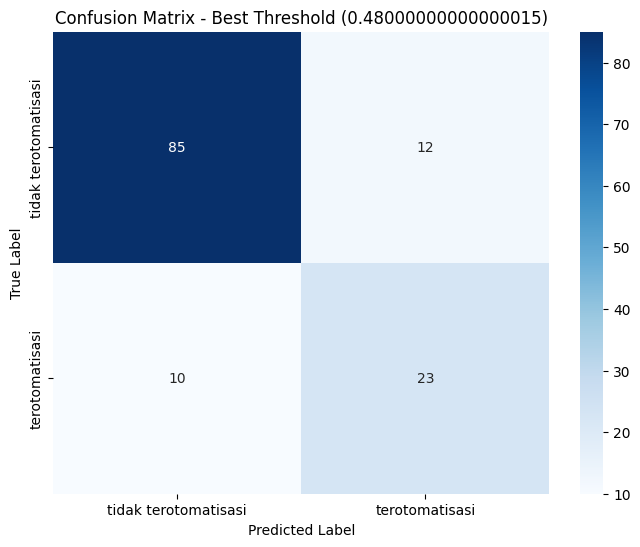

In [126]:
cm_best = confusion_matrix(y_true, best_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=target_names_str, yticklabels=target_names_str)
plt.title(f'Confusion Matrix - Best Threshold ({best_threshold})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

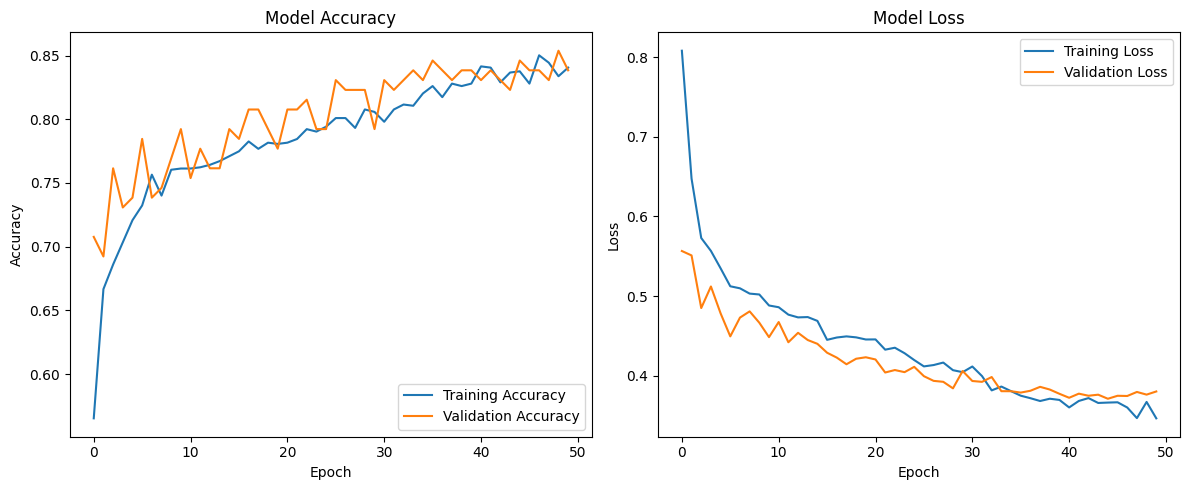

In [127]:
# Grafik Training History (Akurasi & Loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [128]:
# Simpan model
model.save(f'models/{MODEL_ID}.h5')
np.save(f'models/best_threshold_{MODEL_ID}.npy', best_threshold)

# Simpan history dan hasil prediksi
with open(f'results/{MODEL_ID}_history.json', 'w') as f:
    json.dump(history.history, f)

np.save(f'results/{MODEL_ID}_ytrue_test.npy', y_true)
np.save(f'results/{MODEL_ID}_yproba_test.npy', y_proba)

In [129]:
# Load data testing untuk verifikasi teks
df_test = pd.read_csv(f'testing/data_testing_{MODEL_ID}.csv')
X_test_text = df_test['text'].values
print("Variabel dan model berhasil disimpan.")

Variabel dan model berhasil disimpan.


In [130]:
def predict_job_exposure_with_eval(text):
    mode_embed = 'CLS' if CONFIG["pooling"].lower() == 'cls' else 'MEAN'
    embedding = get_bert_embedding(text, mode=mode_embed).reshape(1, -1)
    prediction_prob = model.predict(embedding, verbose=0)

    prob_terotomatisasi = prediction_prob[0][1]
    prob_tidak = prediction_prob[0][0]
    prediction_class = int(prob_terotomatisasi >= best_threshold)

    label_map = {0: "tidak terotomatisasi", 1: "terotomatisasi"}
    print(f"tasks: {text}")
    print(f"prediksi: {label_map[prediction_class]}")
    print(f"confidence terotomatisasi: {prob_terotomatisasi:.2f}")
    print(f"confidence tidak terotomatisasi: {prob_tidak:.2f}")
    print(f"threshold: {best_threshold}")
    print("-" * 30)

#### Cek

In [131]:
# Load history
with open(f'results/{MODEL_ID}_history.json', 'r') as f:
    history_loaded = json.load(f)

# Load model & threshold
model_loaded = load_model(f'models/{MODEL_ID}.h5')
best_threshold_loaded = float(np.load(f'models/best_threshold_{MODEL_ID}.npy'))

y_true_loaded = np.load(f'results/{MODEL_ID}_ytrue_test.npy')
y_proba_loaded = np.load(f'results/{MODEL_ID}_yproba_test.npy')
y_proba_high_loaded = y_proba_loaded[:, 1]

In [132]:
y_pred_best_loaded = (y_proba_high_loaded >= best_threshold_loaded).astype(int)

train_acc_list = history_loaded['accuracy']
val_acc_list = history_loaded['val_accuracy']
train_loss_list = history_loaded['loss']
val_loss_list = history_loaded['val_loss']

epochs = range(1, len(train_acc_list) + 1)
best_epoch_acc = val_acc_list.index(max(val_acc_list)) + 1
best_val_acc = max(val_acc_list)
best_epoch_loss = val_loss_list.index(min(val_loss_list)) + 1
best_val_loss = min(val_loss_list)

print(f"Best Val Acc  : Epoch {best_epoch_acc} = {best_val_acc:.4f}")
print(f"Best Val Loss : Epoch {best_epoch_loss} = {best_val_loss:.4f}")

Best Val Acc  : Epoch 49 = 0.8538
Best Val Loss : Epoch 45 = 0.3711


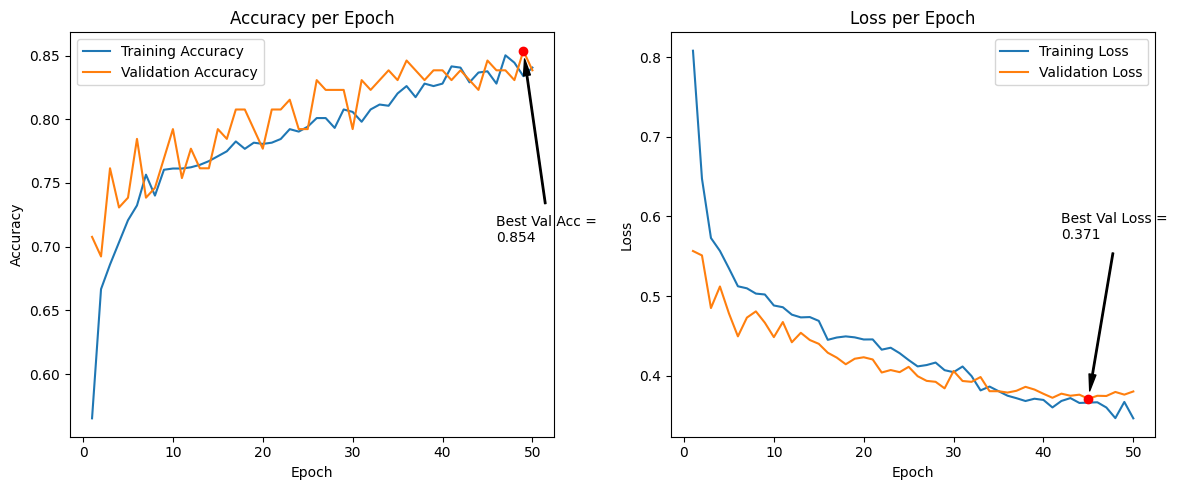

Training berhenti di epoch ke-50


In [133]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc_list, label='Training Accuracy')
plt.plot(epochs, val_acc_list, label='Validation Accuracy')
plt.scatter(best_epoch_acc, best_val_acc, color='red', zorder=5)
plt.annotate(f'Best Val Acc =\n{best_val_acc:.3f}', xy=(best_epoch_acc, best_val_acc),
             xytext=(best_epoch_acc-3, best_val_acc-0.15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss_list, label='Training Loss')
plt.plot(epochs, val_loss_list, label='Validation Loss')
plt.scatter(best_epoch_loss, best_val_loss, color='red', zorder=5)
plt.annotate(f'Best Val Loss =\n{best_val_loss:.3f}', xy=(best_epoch_loss, best_val_loss),
             xytext=(best_epoch_loss-3, best_val_loss+0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Training berhenti di epoch ke-{len(train_acc_list)}")

In [134]:
test_acc_final = accuracy_score(y_true_loaded, y_pred_best_loaded)
y_true_onehot = to_categorical(y_true_loaded, num_classes=2)
test_loss_final = log_loss(y_true_onehot, y_proba_loaded)
f1_final = f1_score(y_true_loaded, y_pred_best_loaded, average='weighted')

print(f"Test Accuracy (Best Threshold): {test_acc_final * 100:.2f}%")
print(f"Test Loss                     : {test_loss_final:.5f}")
print(f"F1 Score (Best Threshold)     : {f1_final:.4f}")

Test Accuracy (Best Threshold): 83.08%
Test Loss                     : 0.41815
F1 Score (Best Threshold)     : 0.8324


In [135]:
cm_final = confusion_matrix(y_true_loaded, y_pred_best_loaded)
tn, fp, fn, tp = cm_final.ravel()

data_distribusi = [
    {"Kelas": "tidak terotomatisasi", "TP": tn, "TN": tp, "FP": fn, "FN": fp},
    {"Kelas": "terotomatisasi", "TP": tp, "TN": tn, "FP": fp, "FN": fn}
]
df_distribusi = pd.DataFrame(data_distribusi)
print("\n=== DISTRIBUSI CONFUSION MATRIX PER KELAS ===")
print(df_distribusi)


=== DISTRIBUSI CONFUSION MATRIX PER KELAS ===
                  Kelas  TP  TN  FP  FN
0  tidak terotomatisasi  85  23  10  12
1        terotomatisasi  23  85  12  10


In [136]:
target_names_str = ['tidak terotomatisasi', 'terotomatisasi']
report_final = classification_report(y_true_loaded, y_pred_best_loaded, target_names=target_names_str, output_dict=True)
df_report = pd.DataFrame(report_final).transpose()
print("\n=== METRIK EVALUASI PER KELAS ===")
print(df_report.iloc[:2, :3])


=== METRIK EVALUASI PER KELAS ===
                      precision    recall  f1-score
tidak terotomatisasi   0.894737  0.876289  0.885417
terotomatisasi         0.657143  0.696970  0.676471


In [137]:
# MENGHITUNG KESALAHAN
misclassified_count = np.sum(y_true_loaded != y_pred_best_loaded)
print(f"\nJumlah data yang salah diklasifikasikan: {misclassified_count} dari {len(y_true_loaded)} data.")

processed_names = []
processed_tasks = []

for text in X_test_text:
    parts = text.split(" [SEP] ")
    name = parts[0]
    tasks_list = parts[1:]

    full_tasks = " [SEP] ".join(tasks_list)

    processed_names.append(name)
    processed_tasks.append(full_tasks)

results_df = pd.DataFrame({
    'Nama Pekerjaan': processed_names,
    'Tugas': processed_tasks,
    'Label Asli': [target_names_str[i] for i in y_true_loaded],
    'Hasil Prediksi': [target_names_str[i] for i in y_pred_best_loaded],
    'Confidence Score': [f"{p*100:.2f}%" for p in y_proba_high_loaded],
    'Status': ['Benar' if a == p else 'Salah' for a, p in zip(y_true_loaded, y_pred_best_loaded)]
})

print("\n--- Contoh Data yang Salah Prediksi ---")
df_salah = results_df[results_df['Status'] == 'Salah']
display(df_salah.head(10))

results_df.to_excel(f'hasil_test/hasil_analisis_{MODEL_ID}.xlsx', index=False)
print(f"\nDisimpan ke 'hasil_test/hasil_analisis_{MODEL_ID}.xlsx'")


Jumlah data yang salah diklasifikasikan: 22 dari 130 data.

--- Contoh Data yang Salah Prediksi ---


,Nama Pekerjaan,Tugas,Label Asli,Hasil Prediksi,Confidence Score,Status
2,Administrator Web,memantau sistem untuk mendeteksi intrusi atau ...,tidak terotomatisasi,terotomatisasi,77.60%,Salah
5,Insinyur Material,menganalisis data kegagalan produk dan hasil u...,tidak terotomatisasi,terotomatisasi,57.86%,Salah
6,Teknisi Mammografi,mengoperasikan alat mammografi digital untuk m...,tidak terotomatisasi,terotomatisasi,58.51%,Salah
20,Ahli Teknik Biomedis,menganalisis sinyal biologis untuk meningkatka...,tidak terotomatisasi,terotomatisasi,85.31%,Salah
38,Operator Pengisian dan Pengemasan,menempelkan label identifikasi pada barang kem...,tidak terotomatisasi,terotomatisasi,60.63%,Salah
44,Ahli Chiropractic,mengevaluasi fungsi sistem neuromuskuloskeleta...,terotomatisasi,tidak terotomatisasi,15.17%,Salah
46,Operator Mesin Produksi Sepatu,memeriksa produk jadi untuk memastikan sepatu ...,tidak terotomatisasi,terotomatisasi,85.84%,Salah
51,Dosen Ilmu Komputer,menyiapkan materi perkuliahan seperti silabus ...,terotomatisasi,tidak terotomatisasi,33.55%,Salah
62,"Petugas Kode Klinik, Petugas Rekam Medis",menghubungi pemegang polis untuk menindaklanju...,terotomatisasi,tidak terotomatisasi,36.31%,Salah
63,Spesialis Sumber Daya Manusia,menafsirkan dan menjelaskan kebijakan prosedur...,terotomatisasi,tidak terotomatisasi,26.50%,Salah



Disimpan ke 'hasil_test/hasil_analisis_M16_801010_CLS_tesLR.xlsx'
